# 부정적분

$F'(x) = f(x)$일 때 $F$를 $f$의 **부정적분**이라 하고

$$
\int f(x)\, dx = F(x) + C
$$

($C$는 적분상수). 미분의 역연산이다.

## 1. sympy.integrate

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')
C = sp.symbols('C')

f = x**2 + 3*x + 2
F = sp.integrate(f, x)

print("f(x) =")
display(f)
print("∫ f(x) dx =")
display(F + C)

# 검산: 미분하면 원래 함수
print("검산 d/dx:")
display(sp.diff(F, x))

f(x) =


∫ f(x) dx =


검산 d/dx:


**sp.integrate(f, x)**: <br>
=> 부정적분 (상수는 보통 생략 → $+C$를 직접 붙임)

**sp.diff로 검산**: <br>
=> $(\int f)' = f$

## 2. 기본 공식 몇 가지

In [3]:
examples = [
    sp.Integer(1),
    x,
    x**2,
    1/x,
    sp.sin(x),
    sp.exp(x),
    (2*x + 1)**3,
]

for expr in examples:
    print("=" * 40)
    display(sp.Eq(sp.Integral(expr, x), sp.integrate(expr, x) + C))

## 3. 선형성

$$
\int (af \pm bg)\,dx = a\int f\,dx \pm b\int g\,dx
$$

In [4]:
f = x**2 + 3*x + 2
g = 3*x**2 + 6*x + 8

print("∫(f+g):")
display(sp.integrate(f + g, x))
print("∫f + ∫g:")
display(sp.integrate(f, x) + sp.integrate(g, x))

print("\n∫(f-g):")
display(sp.integrate(f - g, x))
print("\n∫ 6x² dx:")
display(sp.integrate(6*x**2, x))

∫(f+g):


∫f + ∫g:



∫(f-g):



∫ 6x² dx:


## 4. $+C$의 의미 (그래프 가족)

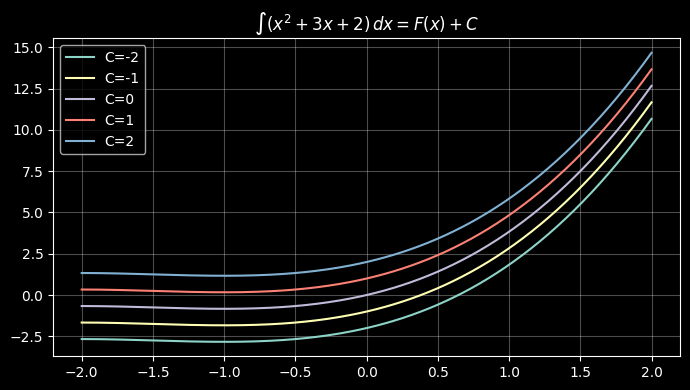

In [5]:
F_num = sp.lambdify(x, F, 'numpy')
xs = np.linspace(-2, 2, 200)

plt.figure(figsize=(7, 4))
for c in [-2, -1, 0, 1, 2]:
    plt.plot(xs, F_num(xs) + c, label=f"C={c}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(r"$\int(x^2+3x+2)\,dx = F(x)+C$")
plt.tight_layout()
plt.show()